# RNNs for Language Modeling task

In [ ]:
!pip install datasets scikit-learn torch matplotlib nltk seaborn

### Import libraries

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

In [ ]:
nltk.download('punkt_tab')

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

### Data preparation

We will use imdb dataset. It contains movies data from imdb website

In [ ]:
# Load dataset
dataset = load_dataset('stanfordnlp/imdb')

### Data preprocessing

In [ ]:
sentences = []
word_threshold = 32

for sentence in tqdm(dataset['train']['text']):
    sentences.extend(
        [x.lower() for x in sent_tokenize(sentence, language='english') if len(word_tokenize(x)) <= word_threshold]
        )

In [7]:
print("Number of sentences:", len(sentences))

Number of sentences: 202657


Let's split sentences into train/test/eval:

In [8]:
train_sentences, temp_sentences = train_test_split(sentences, test_size=0.2, random_state=42)
eval_sentences, test_sentences = train_test_split(temp_sentences, test_size=0.5, random_state=42)


Let's count word frequency:

In [9]:
words = Counter()

for sentence in train_sentences:
    for word in word_tokenize(sentence):
        words[word] += 1

In [10]:
len(words)

62947

Adding ```vocab_size``` most common words to the vocabulary:

In [11]:
vocab_size = 40000
special_tokens = ['<unk>', '<bos>', '<eos>', '<pad>']

vocab_words = [word for word, _ in words.most_common(vocab_size)]
vocab = special_tokens + vocab_words

In [12]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [13]:
print("Total amount of words in vocabulary:", len(vocab))

Total amount of words in vocabulary: 40004


### Dataset preparation

In [14]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [15]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        sentence = self.data[idx]
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in word_tokenize(sentence)]
        tokenized_sentence += [self.eos_id]

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [16]:
def collate_fn_with_padding(
    input_batch: List[List[int]]) -> torch.Tensor:
    pad_id = word2ind['<pad>']
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        padded_sequence = sequence + [pad_id] * (max_seq_len - len(sequence))
        new_batch.append(padded_sequence)

    sequences = torch.LongTensor(new_batch)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [17]:
train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size, shuffle=True)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size, shuffle=False)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size, shuffle=False)

### Evaluation and training functions

In [18]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)

            logits = model(input_ids)

            logits = logits.flatten(start_dim=0, end_dim=1)
            targets = target_ids.flatten()

            loss = criterion(logits, targets)

            total_loss += loss.item()
            total_tokens += (targets != pad_id).sum().item()


        mean_loss = total_loss / total_tokens
        perplexity = torch.exp(torch.tensor(mean_loss)).item()

    return perplexity

In [19]:
def plots(losses, perplexities):

    plt.plot(np.arange(len(losses)), losses)
    plt.title('Losses')
    plt.xlabel("epoch")
    plt.show()

    print(f"Best Perplexity: {min(perplexities):.4f}")

    plt.plot(np.arange(len(perplexities)), perplexities)
    plt.title('Perplexity')
    plt.xlabel("epoch")
    plt.show()

In [20]:
def train_model(model, criterion, optimizer, num_epoch: int, train_dataloader, eval_dataloader,patience: int = 2, min_delta: int = 0.1, save_path="best_model.pt"):
    losses = []
    perplexities = []

    best_perplexity = float("inf")
    epochs_without_improvement = 0

    for epoch in range(num_epoch):
        model.train()

        total_loss = 0.0
        total_tokens = 0

        for batch in tqdm(train_dataloader, desc=f"Training epoch {epoch}:"):
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids).flatten(start_dim = 0, end_dim = 1)
            targets = target_ids.flatten()

            loss = criterion(logits, targets)
            num_tokens = (targets != pad_id).sum()
            loss_for_backward = loss / num_tokens

            loss_for_backward.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            total_loss += loss.item()
            total_tokens += num_tokens.item()

        mean_loss = total_loss / total_tokens
        losses.append(mean_loss)

        perplexity = evaluate(model, criterion, eval_dataloader)
        perplexities.append(perplexity)

        print(
            f"Epoch {epoch}: "
            f"train loss = {mean_loss:.4f}, "
            f"val perplexity = {perplexity:.4f}"
        )

        if perplexity < best_perplexity - min_delta:

            best_perplexity = perplexity
            epochs_without_improvement = 0

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_perplexity": best_perplexity,
                    "hidden_dim": model.embedding.embedding_dim,
                    "vocab_size": model.embedding.num_embeddings,
                },
                save_path
            )

            print(
                f"New best model saved! "
                f"Perplexity: {best_perplexity:.4f}"
            )

        else:
            epochs_without_improvement += 1

            print(
                f"No improvement for "
                f"{epochs_without_improvement} epoch(s)"
            )

            if epochs_without_improvement >= patience:

                print(
                    f"Early stopping at epoch {epoch + 1}. "
                    f"Best perplexity = {best_perplexity:.4f}"
                )
                break

    return losses, perplexities


### Baseline: Basic LSTM with dropout

In [ ]:
class LSTM_base(nn.Module):
    def __init__(self,  hidden_dim, vocab_size, pad_id):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=pad_id)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.projection = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        rnn_output, _ = self.rnn(embeddings)
        output = self.dropout(rnn_output)
        logits = self.projection(output)

        return logits

Training epoch 0::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 0: train loss = 5.3738, val perplexity = 131.4759
New best model saved! Perplexity: 131.4759


Training epoch 1::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 1: train loss = 4.7815, val perplexity = 106.3731
New best model saved! Perplexity: 106.3731


Training epoch 2::   0%|          | 0/1267 [00:00<?, ?it/s]

...

Epoch 5: train loss = 4.1536, val perplexity = 90.0633
New best model saved! Perplexity: 90.0633


Training epoch 6::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 6: train loss = 4.0624, val perplexity = 90.6806
No improvement for 1 epoch(s)


Training epoch 7::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 7: train loss = 3.9812, val perplexity = 91.9024
No improvement for 2 epoch(s)
Early stopping at epoch 8. Best perplexity = 90.0633


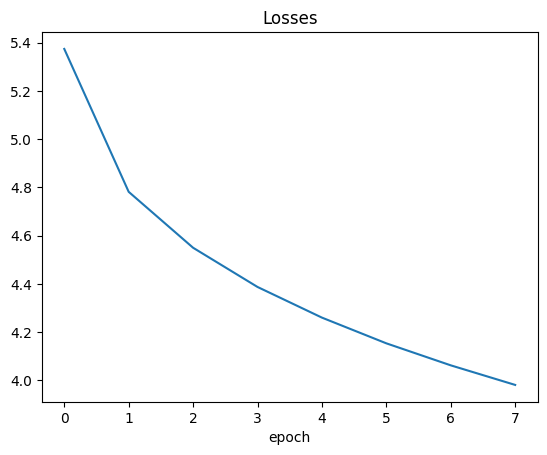

Best Perplexity: 90.0633


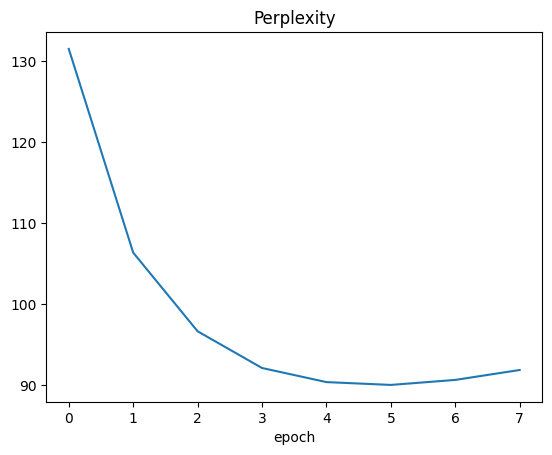

In [ ]:
pad_id = word2ind['<pad>']
model = LSTM_base(hidden_dim=256, vocab_size=len(vocab), pad_id=pad_id).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id, reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

losses, perplexities = train_model(model=model, criterion=criterion, optimizer=optimizer, num_epoch = 10,
    train_dataloader=train_dataloader,
    eval_dataloader=eval_dataloader,
    save_path="best_lstm.pt")

test_perplexity = evaluate(model, criterion, test_dataloader)

plots(losses, perplexities)

In [ ]:
checkpoint = torch.load("best_lstm.pt", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
test_perplexity = evaluate(model, criterion, test_dataloader)
print(f"Test perplexity: {test_perplexity:.4f}")

Test perplexity: 89.5947


### Generation

In [25]:
def generate_sequence(model, starting_seq: str, max_seq_len: int = 30) -> str:
    device = next(model.parameters()).device
    words = word_tokenize(starting_seq)

    input_ids = [word2ind['<bos>']] + [
        word2ind.get(word, word2ind['<unk>']) for word in words]

    input_ids = torch.LongTensor(input_ids).to(device)

    model.eval()
    with torch.no_grad():
        while len(input_ids) < max_seq_len:
            logits = model(input_ids.unsqueeze(0))
            next_word_distribution = logits[0, -1]
            next_word = next_word_distribution.argmax()
            input_ids = torch.cat([input_ids, next_word.unsqueeze(0)])

            if next_word.item() == word2ind['<eos>']:
                break

    generated_words = []

    for idx in input_ids:
        word = ind2word[idx.item()]

        if word == '<bos>': continue
        if word == '<eos>': break

        generated_words.append(word)

    return ' '.join(generated_words)

In [ ]:
generate_sequence(model, starting_seq='meanwhile')

'meanwhile , the <unk> of the film is a bit too much .'

### Experiment 1

Let's icrease hidden_dim from 256 to 512

Training epoch 0::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 0: train loss = 5.1224, val perplexity = 106.4132
New best model saved! Perplexity: 106.4132


Training epoch 1::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 1: train loss = 4.5133, val perplexity = 88.9907
New best model saved! Perplexity: 88.9907


Training epoch 2::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 2: train loss = 4.2215, val perplexity = 84.3904
New best model saved! Perplexity: 84.3904


Training epoch 3::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 3: train loss = 3.9950, val perplexity = 84.3730
No improvement for 1 epoch(s)


Training epoch 4::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 4: train loss = 3.8030, val perplexity = 86.1686
No improvement for 2 epoch(s)
Early stopping at epoch 5. Best perplexity = 84.3904


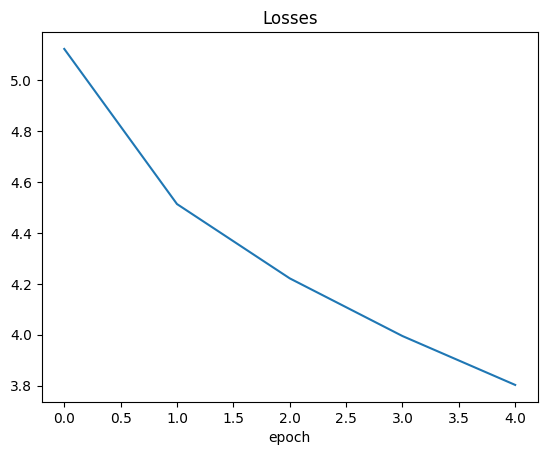

Best Perplexity: 84.3730


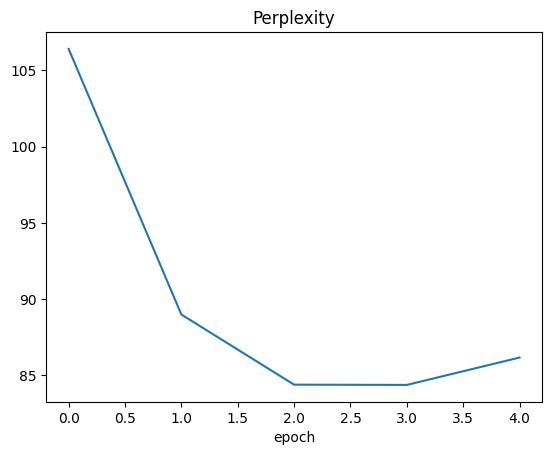

In [ ]:
pad_id = word2ind['<pad>']
model = LSTM_base(hidden_dim=512, vocab_size=len(vocab), pad_id=pad_id).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id, reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

losses, perplexities = train_model(model=model, criterion=criterion, optimizer=optimizer, num_epoch = 10,
    train_dataloader=train_dataloader,
    eval_dataloader=eval_dataloader,
    save_path="best_lstm512.pt")

test_perplexity = evaluate(model, criterion, test_dataloader)

plots(losses, perplexities)

In [ ]:
checkpoint = torch.load("best_lstm512.pt", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
test_perplexity = evaluate(model, criterion, test_dataloader)
print(f"Test perplexity: {test_perplexity:.4f}")

Test perplexity: 83.8547


In [ ]:
generate_sequence(model, starting_seq='meanwhile')

'meanwhile , the <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> ,'

### Experiment 2

Let's increase number of LSTM layers from 1 to 2:

In [ ]:
class LSTM_2l(nn.Module):
    def __init__(self,  hidden_dim, vocab_size, pad_id):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=pad_id)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True, num_layers=2)
        self.projection = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        rnn_output, _ = self.rnn(embeddings)
        output = self.dropout(rnn_output)
        logits = self.projection(output)

        return logits

Training epoch 0::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 0: train loss = 5.4875, val perplexity = 130.8806
New best model saved! Perplexity: 130.8806


Training epoch 1::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 1: train loss = 4.7621, val perplexity = 102.5209
New best model saved! Perplexity: 102.5209


Training epoch 2::   0%|          | 0/1267 [00:00<?, ?it/s]

...

Epoch 4: train loss = 4.1479, val perplexity = 85.2309
New best model saved! Perplexity: 85.2309


Training epoch 5::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 5: train loss = 3.9976, val perplexity = 85.9557
No improvement for 1 epoch(s)


Training epoch 6::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 6: train loss = 3.8601, val perplexity = 88.6345
No improvement for 2 epoch(s)
Early stopping at epoch 7. Best perplexity = 85.2309


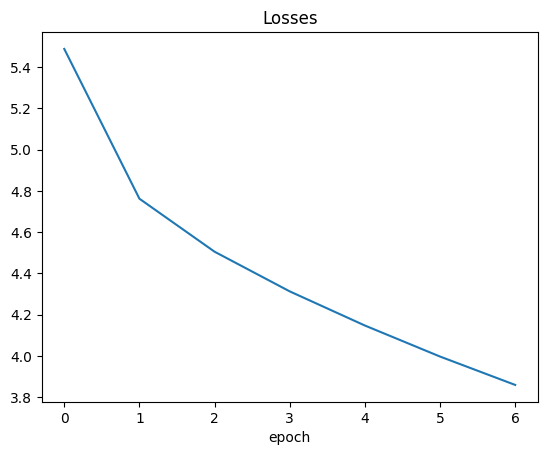

Best Perplexity: 85.2309


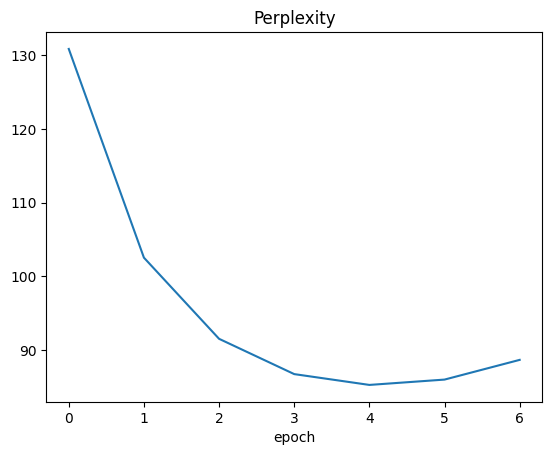

In [ ]:
pad_id = word2ind['<pad>']
model = LSTM_2l(hidden_dim=512, vocab_size=len(vocab), pad_id=pad_id).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id, reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

losses, perplexities = train_model(model=model, criterion=criterion, optimizer=optimizer, num_epoch = 10,
    train_dataloader=train_dataloader,
    eval_dataloader=eval_dataloader,
    save_path="best_lstm_2l.pt")

test_perplexity = evaluate(model, criterion, test_dataloader)

plots(losses, perplexities)

In [ ]:
checkpoint = torch.load("best_lstm_2l.pt", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
test_perplexity = evaluate(model, criterion, test_dataloader)
print(f"Test perplexity: {test_perplexity:.4f}")

Test perplexity: 84.7431


In [ ]:
generate_sequence(model, starting_seq='meanwhile')

'meanwhile , the two main characters are not a good actor , but the film is not a good movie .'

### Experiment 3
Let's replace LSTM layer with GRU layer

In [21]:
class GRU_base(nn.Module):
    def __init__(self,  hidden_dim, vocab_size, pad_id):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=pad_id)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.projection = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        rnn_output, _ = self.rnn(embeddings)
        output = self.dropout(rnn_output)
        logits = self.projection(output)

        return logits

Training epoch 0::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 0: train loss = 5.2676, val perplexity = 118.6150
New best model saved! Perplexity: 118.6150


Training epoch 1::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 1: train loss = 4.6814, val perplexity = 99.6881
New best model saved! Perplexity: 99.6881


Training epoch 2::   0%|          | 0/1267 [00:00<?, ?it/s]

...

Epoch 4: train loss = 4.1690, val perplexity = 91.0843
New best model saved! Perplexity: 91.0843


Training epoch 5::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 5: train loss = 4.0629, val perplexity = 91.8679
No improvement for 1 epoch(s)


Training epoch 6::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 6: train loss = 3.9730, val perplexity = 93.1276
No improvement for 2 epoch(s)
Early stopping at epoch 7. Best perplexity = 91.0843


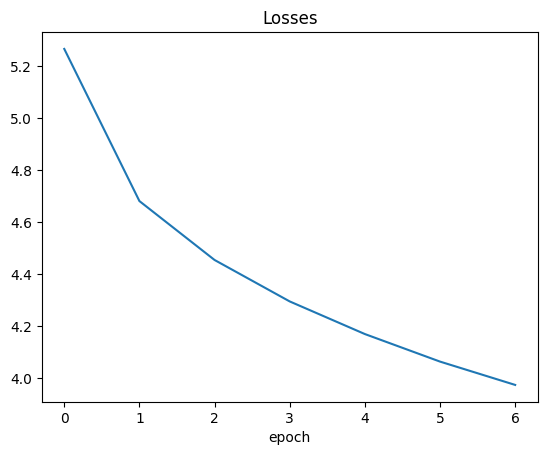

Best Perplexity: 91.0843


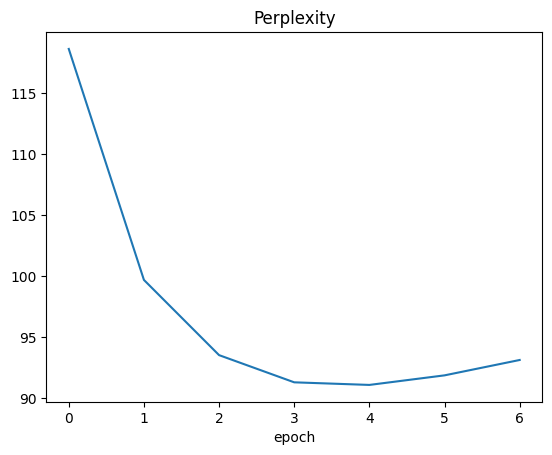

In [ ]:
pad_id = word2ind['<pad>']
model = GRU_base(hidden_dim=256, vocab_size=len(vocab), pad_id=pad_id).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id, reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

losses, perplexities = train_model(model=model, criterion=criterion, optimizer=optimizer, num_epoch = 10,
    train_dataloader=train_dataloader,
    eval_dataloader=eval_dataloader,
    save_path="best_gru.pt")

test_perplexity = evaluate(model, criterion, test_dataloader)

plots(losses, perplexities)

In [ ]:
checkpoint = torch.load("best_gru.pt", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
test_perplexity = evaluate(model, criterion, test_dataloader)
print(f"Test perplexity: {test_perplexity:.4f}")

Test perplexity: 90.4427


In [ ]:
generate_sequence(model, starting_seq='meanwhile')

'meanwhile , the man is a jerk , but he is a little too .'

### Experiment 4

Let's icrease hidden_dim from 256 to 512

Training epoch 0::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 0: train loss = 5.0708, val perplexity = 100.7934
New best model saved! Perplexity: 100.7934


Training epoch 1::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 1: train loss = 4.4489, val perplexity = 88.5701
New best model saved! Perplexity: 88.5701


Training epoch 2::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 2: train loss = 4.1321, val perplexity = 87.3353
New best model saved! Perplexity: 87.3353


Training epoch 3::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 3: train loss = 3.8773, val perplexity = 89.8721
No improvement for 1 epoch(s)


Training epoch 4::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 4: train loss = 3.6721, val perplexity = 93.9570
No improvement for 2 epoch(s)
Early stopping at epoch 5. Best perplexity = 87.3353


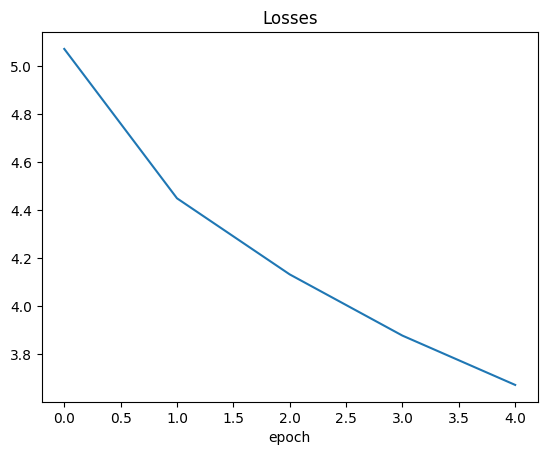

Best Perplexity: 87.3353


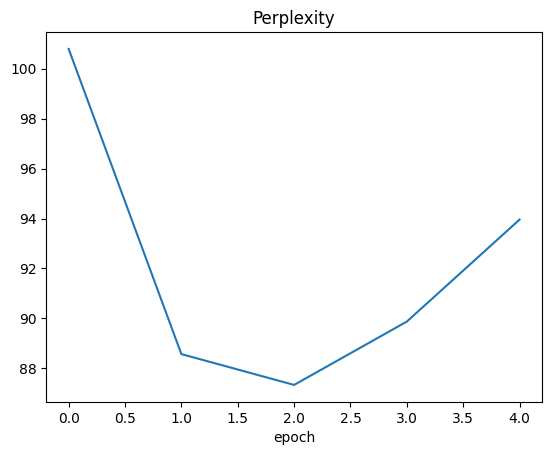

In [22]:
pad_id = word2ind['<pad>']
model = GRU_base(hidden_dim=512, vocab_size=len(vocab), pad_id=pad_id).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id, reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

losses, perplexities = train_model(model=model, criterion=criterion, optimizer=optimizer, num_epoch = 10,
    train_dataloader=train_dataloader,
    eval_dataloader=eval_dataloader,
    save_path="best_gru512.pt")

test_perplexity = evaluate(model, criterion, test_dataloader)

plots(losses, perplexities)

In [23]:
checkpoint = torch.load("best_gru512.pt", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
test_perplexity = evaluate(model, criterion, test_dataloader)
print(f"Test perplexity: {test_perplexity:.4f}")

Test perplexity: 86.5969


In [26]:
generate_sequence(model, starting_seq='meanwhile')

"meanwhile , the <unk> ' is a bit more than a <unk> ' ."

In [27]:
generate_sequence(model, starting_seq='what')

'what a waste of talent .'

### Experiment 5

Let's increase number of GRU layers from 1 to 2

In [28]:
class GRU_2l(nn.Module):
    def __init__(self,  hidden_dim, vocab_size, pad_id):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=pad_id)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True, num_layers=2)
        self.projection = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        rnn_output, _ = self.rnn(embeddings)
        output = self.dropout(rnn_output)
        logits = self.projection(output)

        return logits

Training epoch 0::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 0: train loss = 5.1881, val perplexity = 106.8790
New best model saved! Perplexity: 106.8790


Training epoch 1::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 1: train loss = 4.5583, val perplexity = 89.9800
New best model saved! Perplexity: 89.9800


Training epoch 2::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 2: train loss = 4.2742, val perplexity = 85.6320
New best model saved! Perplexity: 85.6320


Training epoch 3::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 3: train loss = 4.0406, val perplexity = 86.1858
No improvement for 1 epoch(s)


Training epoch 4::   0%|          | 0/1267 [00:00<?, ?it/s]

Epoch 4: train loss = 3.8320, val perplexity = 89.3152
No improvement for 2 epoch(s)
Early stopping at epoch 5. Best perplexity = 85.6320


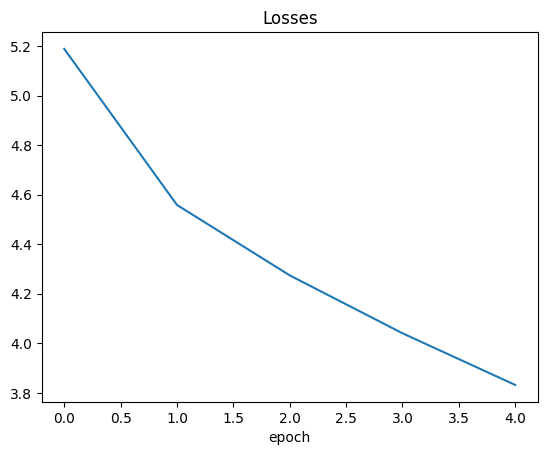

Best Perplexity: 85.6320


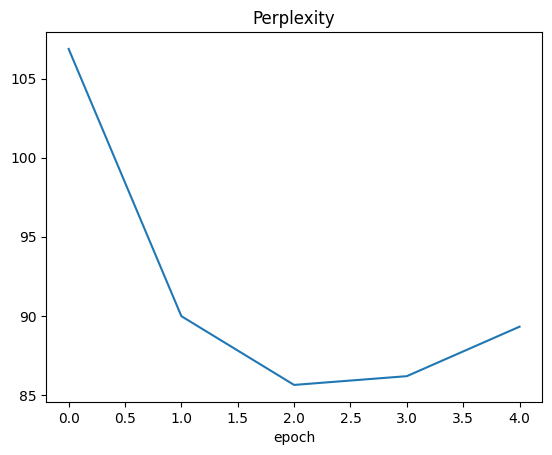

In [29]:
pad_id = word2ind['<pad>']
model = GRU_2l(hidden_dim=512, vocab_size=len(vocab), pad_id=pad_id).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id, reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

losses, perplexities = train_model(model=model, criterion=criterion, optimizer=optimizer, num_epoch = 10,
    train_dataloader=train_dataloader,
    eval_dataloader=eval_dataloader,
    save_path="best_gru_2l.pt")

test_perplexity = evaluate(model, criterion, test_dataloader)

plots(losses, perplexities)

In [30]:
checkpoint = torch.load("best_gru_2l.pt", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
test_perplexity = evaluate(model, criterion, test_dataloader)
print(f"Test perplexity: {test_perplexity:.4f}")

Test perplexity: 84.9984


In [31]:
generate_sequence(model, starting_seq='meanwhile')

'meanwhile , the film is a very good film .'

In [32]:
generate_sequence(model, starting_seq='what')

'what a waste of time .'

### Conclusion

| model     | hidden_dim | test perplexity |
| --------- | ---------- | --------------- |
| LSTM_base | 256        | 89.5947         |
| LSTM_base | 512        | 83.8547         |
| LSTM_2l   | 512        | 84.7431         |
| GRU_base  | 256        | 91.0843         |
| GRU_base  | 512        | 86.5969         |
| GRU_2l    | 512        | 84.9984         |

Increasing the hidden dimension from 256 to 512 consistently improves language-model performance for both LSTM and GRU. Adding a second recurrent layer does not improve over the 1-layer 512-dimensional LSTM/GRU models, although the 2-layer GRU comes close. Overall, the 1-layer LSTM with hidden dimension 512 achieves the best test perplexity (83.85).